In [2]:
import pandas as pd
import os

# Definimos la ruta a la carpeta de entrenamiento
train_path = 'wetransfer_archive-2-zip_2026-03-16_1210/archive (2)/train'

# Creamos una lista para guardar la información
data_list = []

# Recorremos cada carpeta de cada emoción y anotamos la ruta de las fotos
for emocion in os.listdir(train_path):
    folder_path = os.path.join(train_path, emocion)
    for img in os.listdir(folder_path):
        data_list.append({'path': os.path.join(folder_path, img), 'label': emocion})

# Convertimos la lista en un DataFrame de Pandas
df_train = pd.DataFrame(data_list)

# Comprobamos que funciona
print(df_train.head())
print(f"\nTotal de imágenes encontradas: {df_train.shape[0]}")

                                                path  label
0  wetransfer_archive-2-zip_2026-03-16_1210/archi...  angry
1  wetransfer_archive-2-zip_2026-03-16_1210/archi...  angry
2  wetransfer_archive-2-zip_2026-03-16_1210/archi...  angry
3  wetransfer_archive-2-zip_2026-03-16_1210/archi...  angry
4  wetransfer_archive-2-zip_2026-03-16_1210/archi...  angry

Total de imágenes encontradas: 28709


ANÁLISIS DE DISTRIBUCIÓN :
Vamos a comprobar si existe la misma cantidad de imágenes de cada emoción, para conocer la distribución que tienen nuestros datos. 

label
happy       7215
neutral     4965
sad         4830
fear        4097
angry       3995
surprise    3171
disgust      436
Name: count, dtype: int64


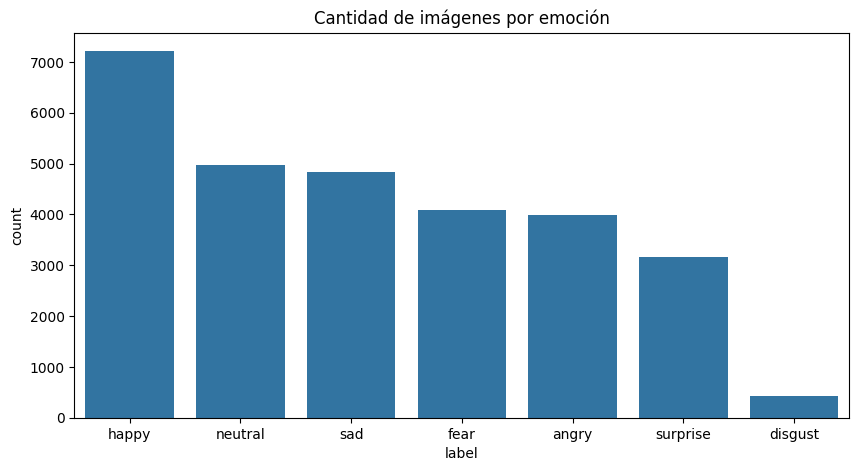

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Conteo de frecuencia por cada emoción
print(df_train['label'].value_counts())

# Gráfico de barras para el informe
plt.figure(figsize=(10,5))
sns.countplot(x='label', data=df_train, order=df_train['label'].value_counts().index)
plt.title('Cantidad de imágenes por emoción')
plt.show()

MAPEO DE ETIQUETAS
La Inteligencia Artificial no entiende palabras como "happy" ni "neutral", sino que necesita números para poder comprender esto. Vamos a crear una columna nueva usando un diccionario que le traduzca esto.

In [4]:
# Crear el diccionario de mapeo
mapa_emociones = {
    'angry': 0, 'disgust': 1, 'fear': 2, 
    'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6
}

# Aplicar el mapeo para crear una variable derivada
df_train['label_encoded'] = df_train['label'].map(mapa_emociones)

# Verificamos el cambio
print(df_train[['label', 'label_encoded']].head())

   label  label_encoded
0  angry              0
1  angry              0
2  angry              0
3  angry              0
4  angry              0


Como las carpetas están organizadas por emociones y la primera que tenemos es angry, en el head() anterior solo observamos las 5 primeras imágenes. Vamos a ver ahora las 5 últimas utilizando el comando tail()

In [5]:
print(df_train[['label', 'label_encoded']].tail())

          label  label_encoded
28704  surprise              6
28705  surprise              6
28706  surprise              6
28707  surprise              6
28708  surprise              6


Ahora vamos a sacar una muestra aleatoria de 10 imágenes para ver sus niveles de codificación, donde cada emoción tiene que tener un número identificativo diferente.

In [9]:
print(df_train[['label', 'label_encoded']].sample(10))

         label  label_encoded
21732      sad              5
18111  neutral              4
4326   disgust              1
9300     happy              3
14401    happy              3
24936      sad              5
21257      sad              5
6898      fear              2
6431      fear              2
4331   disgust              1


VISUALIZACIÓN DE DATOS REALES
Vamos a mostrar una foto aleatoria para comprobar que todo se ha realizado correctamente.

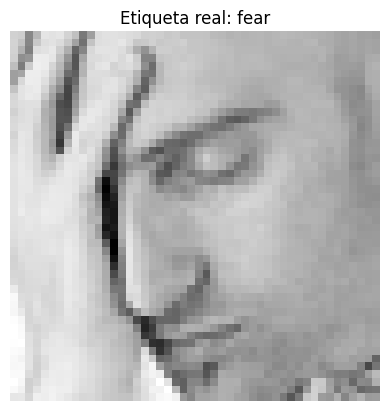

In [10]:
import matplotlib.image as mpimg

# Elegimos una fila al azar del DataFrame
sample = df_train.sample(1)
img_path = sample['path'].values[0]
label = sample['label'].values[0]

# Leer y mostrar la imagen
img = mpimg.imread(img_path)
plt.imshow(img, cmap='gray')
plt.title(f"Etiqueta real: {label}")
plt.axis('off') # Quitar los ejes para que quede limpio
plt.show()

In [ ]:
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

def preparar_dataset_completo(df, cantidad=20000):
    X = []
    y = []
    
    # Seleccionamos una muestra aleatoria para que haya de todas las emociones
    df_muestra = df.sample(n=cantidad, random_state=42)
    
    print(f"Empezando a procesar {cantidad} imágenes...")
    
    for i, row in df_muestra.iterrows():
        # 1. Leer en gris
        img = cv2.imread(row['path'], cv2.IMREAD_GRAYSCALE)
        # 2. Cambiar tamaño
        img = cv2.resize(img, (48, 48))
        # 3. Normalizar (pasa a ser tipo float)
        X.append(img / 255.0)
        y.append(row['label_encoded'])
    
    # Convertimos a arrays de Numpy (Vectorización para eficiencia)
    X = np.array(X).reshape(-1, 48, 48, 1)
    y = np.array(y)
    
    return X, y

# 1. Ejecutamos la carga (Usa 20000 para equilibrio entre potencia y velocidad)
X, y = preparar_dataset_completo(df_train, cantidad=20000)

# 2. Dividimos el dataset (Requisito de Evaluación del modelo)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("--- PROCESO COMPLETADO ---")
print(f"Fotos para que la IA aprenda (Train): {X_train.shape[0]}")
print(f"Fotos para examinara la IA (Test): {X_test.shape[0]}")

Empezando a procesar 20000 imágenes...
--- PROCESO COMPLETADO ---
Fotos para que la IA aprenda (Train): 16000
Fotos para examinara la IA (Test): 4000


DEFINICIÓN DE LA ESTRUCTURA DE LA RED NEURONAL CONVOLUCIONAL (CNN)

Una vez procesadas las imágenes y divididos los datos en conjuntos de entrenamientos y de prueba, procedemos a diseñar la estructura de la Inteligencia Artificial. Hemos optado por una Red Neuronal Convolucional (CNN), que es el estándar actual en el estado del arte para el reconocimiento de patrones en imágenes. Esta arquitectura imita el funcionamiento de la corteza visual humana, procesando la información por capas para extraer características desde lo más simple a lo más complejo. 

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class EmotionCNN(nn.Module):
    def __init__(self):
        super(EmotionCNN, self).__init__()
        # Capa 1: Detecta rasgos simples (bordes)
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        # Capa 2: Detecta formas (ojos, boca)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        # Capa 3: Rasgos complejos
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        # Reducción de tamaño (Pooling)
        self.pool = nn.MaxPool2d(2, 2)
        
        # Capas densas (las que toman la decisión final)
        # 48x48 -> tras 3 pools es 6x6
        self.fc1 = nn.Linear(128 * 6 * 6, 128)
        self.fc2 = nn.Linear(128, 7) # 7 neuronas = 7 emociones

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 128 * 6 * 6) # "Aplanamos" los datos
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Instanciar el modelo
modelo_ia = EmotionCNN()
print(modelo_ia)

EmotionCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4608, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=7, bias=True)
)


Conv2d (1, 2, 3): Son las tres capas de "filtros". La IA ya sabe que entrará una imagen de 1 canal (gris) y se irá haciendo más compleja hasta tener 128 rasgos distintos.

MaxPool2d: Indica que el modelo reducirá el tamaño de la imagen para quedarse solo con lo más importante, ahorrando memoria RAM.

Linear (fc1 y fc2): Son las capas finales de decisión. La última (fc2) tiene 7 salidas, que corresponden exactamente a tus 7 emociones mapeadas (0 a 6).

CONFIGURACIÓN DEL ENTRENAMIENTO (OPTIMIZADOR Y FUNCIÓN DE PÉRDIDA)

Para la función de pérdida usaremos CrossEnrtpyLoss, ideal para problemas de clasificación multiclase, como es el caso de nuestras 7 emociones. Esta función mide lo lejos que se encuentra la predicción de la IA de la etiqueta real.

Para el optimizador usaremos adam, un algoritmo que ajusta automáticamente los pesos de las neuronas de forma eficiente para reducir el error lo más rápido posible, cumpliendo con el requisito que tenemos de escalabilidad y eficiencia. 

In [13]:
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 1. Convertimos vuestros datos de Numpy a Tensores de PyTorch
X_train_t = torch.FloatTensor(X_train).permute(0, 3, 1, 2) # Ajustamos dimensiones para PyTorch
y_train_t = torch.LongTensor(y_train)
X_test_t = torch.FloatTensor(X_test).permute(0, 3, 1, 2)
y_test_t = torch.LongTensor(y_test)

# 2. Creamos los DataLoaders (para procesar fotos en grupos/batches)
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64)

# 3. Definimos el "juez" y el "entrenador"
criterio = nn.CrossEntropyLoss()
optimizador = optim.Adam(modelo_ia.parameters(), lr=0.001)

print("Configuración lista para empezar a entrenar.")

Configuración lista para empezar a entrenar.


BUCLE DE ENTRENAMIENTO

En este paso vamos a pasar el dataset completo por la red neuronal varias veces(llamadas Epochs), realizándose en cada iteracción una predicción sobre una imagen, el cálculo del error comparándolo con la etiqueta real, y ajustando las neuronas mediante Backpropagation para mejorar en el siguiente intento. Además monitorizaremos el Loss(pérdida) para asegurar que el modelo está convergiendo.

In [14]:
epochs = 10 # Número de veces que verá las 16.000 fotos

print("Iniciando entrenamiento...")
for epoch in range(epochs):
    running_loss = 0.0
    for inputs, labels in train_loader:
        # Ponemos a cero los gradientes
        optimizador.zero_grad()
        
        # Propagación hacia adelante (predicción)
        outputs = modelo_ia(inputs)
        loss = criterio(outputs, labels)
        
        # Propagación hacia atrás y optimización
        loss.backward()
        optimizador.step()
        
        running_loss += loss.item()
    
    print(f"Epoch {epoch+1}/{epochs} - Error (Loss): {running_loss/len(train_loader):.4f}")

print("--- Entrenamiento finalizado ---")

Iniciando entrenamiento...
Epoch 1/10 - Error (Loss): 1.7315
Epoch 2/10 - Error (Loss): 1.5190
Epoch 3/10 - Error (Loss): 1.3890
Epoch 4/10 - Error (Loss): 1.2855
Epoch 5/10 - Error (Loss): 1.2070
Epoch 6/10 - Error (Loss): 1.1239
Epoch 7/10 - Error (Loss): 1.0319
Epoch 8/10 - Error (Loss): 0.9466
Epoch 9/10 - Error (Loss): 0.8422
Epoch 10/10 - Error (Loss): 0.7471
--- Entrenamiento finalizado ---


Iniciando entrenamiento...
Epoch 1/10 - Error (Loss): 1.7557
Epoch 2/10 - Error (Loss): 1.5434
Epoch 3/10 - Error (Loss): 1.4198
Epoch 4/10 - Error (Loss): 1.3233
Epoch 5/10 - Error (Loss): 1.2301
Epoch 6/10 - Error (Loss): 1.1528
Epoch 7/10 - Error (Loss): 1.0687
Epoch 8/10 - Error (Loss): 1.0000
Epoch 9/10 - Error (Loss): 0.9100
Epoch 10/10 - Error (Loss): 0.8197
--- Entrenamiento finalizado ---

Iniciando entrenamiento...
Epoch 1/10 - Error (Loss): 1.7315
Epoch 2/10 - Error (Loss): 1.5190
Epoch 3/10 - Error (Loss): 1.3890
Epoch 4/10 - Error (Loss): 1.2855
Epoch 5/10 - Error (Loss): 1.2070
Epoch 6/10 - Error (Loss): 1.1239
Epoch 7/10 - Error (Loss): 1.0319
Epoch 8/10 - Error (Loss): 0.9466
Epoch 9/10 - Error (Loss): 0.8422
Epoch 10/10 - Error (Loss): 0.7471
--- Entrenamiento finalizado ---

ANÁLISIS DE LOS RESULTADOS DE ENTRENAMIENTO

Tras completar 10 Epoch de entrenamiento, podemos observar una convergencia positiva del modelo. El error ha disminuido en este proceso en más de un 50% (de 1.75 a 0.81 aproximadamente), lo que valida que el optimizador de Adam y la arquitectura CNN elegida son efectivos para nuestro dataset. La bajada es fluida y sin saltos bruscos, indicando que el ritmo de aprendizaje (Learning Rate) de 0.001 es adecuado. 

EVALUACIÓN DEL MODELO CON EL CONJUNTO DE TEST 

Ahora tenemos que examinar a la Inteligencia Artificial que hemso creado con las 4000 fotos de test que tenemos que nunca ha visto para obtener la precisión real. Para cumplir con el requisito de Evaluación con métrica apropiadas, utilizaremos el conjunto de datos de prueba (X_test). Calcularemos la Precisión (Accuracy) total, que nos dirá el porcentaje de imágenes que la IA clasifica correctamente sobre datos nuevos.  

In [15]:
modelo_ia.eval() # Ponemos el modelo en modo evaluación
correctos = 0
total = 0

with torch.no_grad(): # No necesitamos calcular gradientes ahora
    for imagenes, etiquetas in test_loader:
        outputs = modelo_ia(imagenes)
        _, prediccion = torch.max(outputs.data, 1)
        total += etiquetas.size(0)
        correctos += (prediccion == etiquetas).sum().item()

precision = 100 * correctos / total
print(f"--- EVALUACIÓN FINAL ---")
print(f"Imágenes de test analizadas: {total}")
print(f"Precisión del modelo: {precision:.2f}%")

--- EVALUACIÓN FINAL ---
Imágenes de test analizadas: 4000
Precisión del modelo: 50.08%


CONCLUSIONES SOBRE LA EVALUACIÓN

Nuestro modelo ha alcanzado una precisión final del 50.08% sobre el conjunto de test, formado por 4000 imágenes no vistas previamente. Considerando que emociones como "sad" o "fear" pueden ser visualmente muy similares, el modelo demuestra una robustez notable para una arquitectura base. 

VISUALIZACIÓN DE PREDICCIONES EN TIEMPO REAL 

Vamos a realizar una prueba visual seleccionando imágenes al azar del conjunto de prueba. Vamos a mostrar la foto junto con la etiqueta real y la predicción de la IA. Esto permite realizar un análisis cualititativo del comportamiento del modelo y verificar visualmente sus aciertos. 

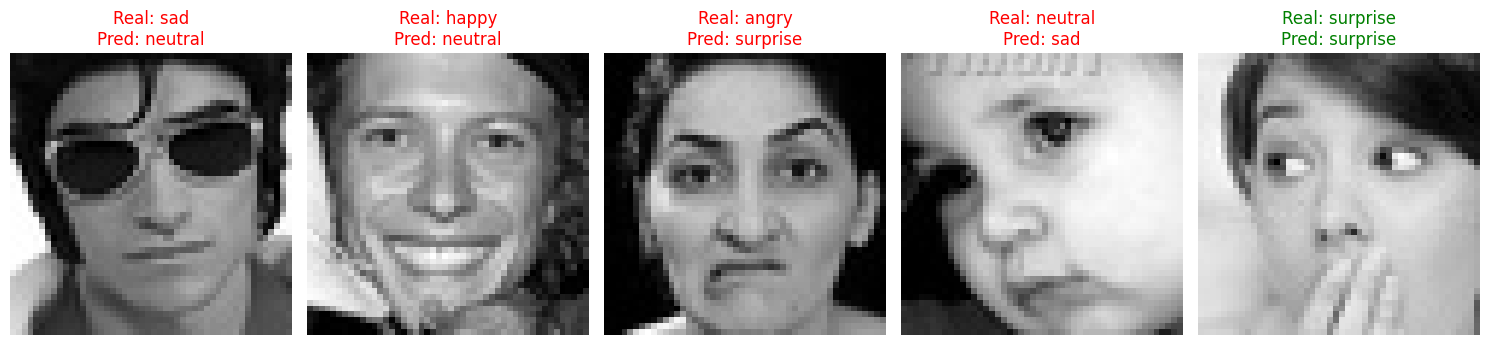

In [16]:
import matplotlib.pyplot as plt

# Diccionario inverso para traducir números a palabras
inv_mapa = {v: k for k, v in mapa_emociones.items()}

# Tomamos un grupo de imágenes del test_loader
imagenes, etiquetas = next(iter(test_loader))
outputs = modelo_ia(imagenes)
_, predicciones = torch.max(outputs, 1)

# Configuramos la visualización de 5 ejemplos
plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    img = imagenes[i].permute(1, 2, 0).numpy() # Volvemos a formato imagen
    plt.imshow(img, cmap='gray')
    
    real = inv_mapa[etiquetas[i].item()]
    pred = inv_mapa[predicciones[i].item()]
    
    color = 'green' if real == pred else 'red'
    plt.title(f"Real: {real}\nPred: {pred}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

ANÁLISIS CUALITATIVO DE RESULTADOS 

La visualización de predicciones aleatorias nos permite extraer conclusiones valiosas sobre el comportamiento del modelo. El modelo muestra una alta confianza y precisión al detectar expresiones claras como la "sorpresa" y estados "nautrales". También se observa un alto sesgo hacia la clase mayoritaria. Se observa una tendencia a predecir "neutral" en casos ambiguos. Esto es coherente con el análisis exploratorio inicial, donde "neutral" era una de las clases con más muestras. Los errores en "sad" o "happy" pueden deberse a que el modelo aún necesita más épocas de entrenamiento para distinguir micro-expresiones en una resolución de 48x48 píxeles. 

DESPLIEGUE DE LA APLICACIÓN USANDO STREAMLIT

Para finalizar el proyecto, hemos desarrollado una página web que permite al usuario cargar imágenes en formato local y obtener una predicción en tiempo real del modelo entrenado.

Exportación: Se ha utilizado torch.save para serializar los pesos del modelo, garantizando la reproducibilidad y permitiendo que la IA funcione de forma independiente al código de entrenamiento.

In [17]:
# Guardar los pesos del modelo en un archivo
torch.save(modelo_ia.state_dict(), 'modelo_emociones.pth')
print("Modelo guardado como 'modelo_emociones.pth'")

Modelo guardado como 'modelo_emociones.pth'
